# Calculo de Eigenvalores para un modelo de BTC (Boundary Time Crystals) https://arxiv.org/abs/1708.05014
 Importamos librerias importantes, principalmente qutip que ya nos hace la vectorización para el Liouvilliano y para definir los operadores e incluso para realizar los productos tensoriales de manera sencilla

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

vec1= basis(5,2) 
up = basis(2,0) # (1,0)
down = basis(2,1) # (0,1)

upx = (basis(2,0) + basis(2,1)).unit() # Initial state “The system is initialised in the pure state with all spins aligned along the x-direction…”

Probando como hacer matrices de densidad y trazas parciales usando las funciones de qutip

In [5]:
# Matriz de densidad para 2 espines

psi = (1/np.sqrt(2))*(1/np.sqrt(2))*(tensor(up,down) - tensor(down,up)) 

rho = psi * psi.dag()

rho_0 = rho.ptrace(0) # Tr_1 rho
rho_1 = rho.ptrace(1)

## Queremos obtener los eigenvalores del Liouvilliano
En general y en la función de qutip 

$$\mathcal{L}[\rho] = i[\rho, H] + \left( L\rho L^{\dagger} - \frac{1}{2} \{L^{\dagger}L, \rho\} \right) = \lambda \rho$$

En el modelo usan el siguiente Hamiltoniano

$$H = \omega_0 \sum_j \sigma^x_j$$
En el paper usan la siguiente expresión ya simplificada

$$\mathcal{L}[\rho] = i\omega_0[\rho, S^x] + \frac{\kappa}{S}\left( S_{-}\rho S_{+} - \frac{1}{2} \{S_{+}S_{-}, \rho\} \right)$$


In [2]:
import numpy as np
from qutip import *

# Graphs
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Para guardar los datos
import os
import pickle

In [3]:

def build_system(Nb): # Nb: Spin en la frontera
    S = Nb/2 # Spin total
    k = 1
    w_0 = 1.5*k 
    
# Defining spin operators
    Sx = jmat(S, 'x')
    Sy = jmat(S, 'y')
    Sz = jmat(S, 'z')
    S2 = Sx**2 + Sy**2 + Sz**2
    Sm = np.sqrt(k/S)*jmat(S, '-')

# Hamiltonian
    H = w_0*Sx

    jump_ops = [Sm]
    expected_ops = [S2,Sx,Sy,Sz]
    
    return H, jump_ops, expected_ops, S
"""------------------------------------------------------------------------------------"""        
def do_spectrum(Nb):
    H, jump_ops, _, _ = build_system(Nb)

    L = liouvillian(H, jump_ops)
    eigs = L.eigenenergies()

    return eigs
"""------------------------------------------------------------------------------------"""
def simulation(Nb):

    H, jump_ops, exp_ops, S = build_system(Nb)
#  All spins up in z i.e |S, M=S>, for ini state
    psi_z = basis(int(2*S+1), 0)

#  Rotando pi/2
#  U = (-1j * np.pi/2 * Sy).expm()
#  psi_x = U * psi_z
    psi_x = spin_coherent(S, np.pi/2, 0)
    rho0x = psi_x * psi_x.dag()
    rho0z = psi_z * psi_z.dag()

    t = np.linspace(0, 60, 200)
    
    evo = mesolve(H, rho0x, t, jump_ops, exp_ops)
    #evo2 = mesolve(H, rho0z, t, jump_ops, expected_ops)
    return evo


results = {}
eigenvalues = {}

In [41]:
"""
Este bloque sirve para guardar los datos obtenidos, eigenvalores y dinamica. Usando os & pickle
"""

# CORRECTED VERSION
RESULTS_DIR = 'btc_results'
os.makedirs(RESULTS_DIR, exist_ok=True)

def get_file_paths(Nb):
    """Get paths WITHOUT forcing .qu extension"""
    eigen_file = os.path.join(RESULTS_DIR, f'btc_eigenvalues_Nb_{Nb}.npz')
    sim_file_base = os.path.join(RESULTS_DIR, f'btc_simulation_Nb_{Nb}')
    return eigen_file, sim_file_base

def save_results_complete(Nb_list, results_dict, eigenvalues_dict, force_overwrite=False):
    """Save both eigenvalues and simulation results"""
    
    for Nb in Nb_list:
        # Save eigenvalues
        eigen_file = os.path.join(RESULTS_DIR, f'btc_eigenvalues_Nb_{Nb}.npz')
        if force_overwrite or not os.path.exists(eigen_file):
            np.savez_compressed(eigen_file, 
                               eigenvalues=eigenvalues_dict[Nb],
                               Nb=Nb,
                               S=Nb/2,
                               timestamp=time.time())
            print(f"✓ Saved eigenvalues for Nb={Nb}")
        else:
            print(f"⏭️  Eigenvalues for Nb={Nb} already exist")
        
        # Save simulation - let qsave handle extension
        sim_file_base = os.path.join(RESULTS_DIR, f'btc_simulation_Nb_{Nb}')
        sim_file_with_ext = sim_file_base + '.qu'
        
        if force_overwrite or not os.path.exists(sim_file_with_ext):
            qsave(results_dict[Nb], sim_file_base)
            print(f"✓ Saved simulation for Nb={Nb}")
        else:
            print(f"⏭️  Simulation for Nb={Nb} already exist")

def load_results_complete(Nb):
    """Load results - let qload handle the extension"""
    eigen_file = os.path.join(RESULTS_DIR, f'btc_eigenvalues_Nb_{Nb}.npz')
    sim_file_base = os.path.join(RESULTS_DIR, f'btc_simulation_Nb_{Nb}')  # NO .qu extension!
    
    print(f"Looking for eigen file: {os.path.basename(eigen_file)}")
    print(f"Looking for sim file base: {os.path.basename(sim_file_base)}")
    
    # Load eigenvalues
    eigenvalues = None
    if os.path.exists(eigen_file):
        data = np.load(eigen_file)
        eigenvalues = data['eigenvalues']
        print(f"✓ Loaded eigenvalues for Nb={Nb}")
    else:
        print(f"✗ No eigen file found for Nb={Nb}")
    
    # Load simulation - let qload add the .qu extension automatically
    results = None
    try:
        # qload will automatically add .qu, so don't add it yourself
        results = qload(sim_file_base)
        print(f"✓ Loaded simulation for Nb={Nb}")
    except FileNotFoundError:
        print(f"✗ No sim file found for Nb={Nb}")
    except Exception as e:
        print(f"✗ Error loading simulation for Nb={Nb}: {e}")
    
    return eigenvalues, results

# =====================================================================================================================================================================  
# Computation function with checkpoint at every Nb
# =====================================================================================================================================================================
def compute_btc_system(Nb_list, force_recompute=False):
    """Main computation with checkpointing"""
    
    results = {}
    eigenvalues = {}
    
    for Nb in Nb_list:
        print(f"\n{'='*50}")
        print(f"Processing Nb = {Nb}")
        
        eigen_file, sim_file_base = get_file_paths(Nb)
        sim_file = sim_file_base + '.qu'  # Expected final file
        
        # Check if files exist
        eigen_exists = os.path.exists(eigen_file) and os.path.getsize(eigen_file) > 0
        sim_exists = os.path.exists(sim_file) and os.path.getsize(sim_file) > 0
        
        print(f"  Eigen file exists: {eigen_exists} ({os.path.getsize(eigen_file) if eigen_exists else 0} bytes)")
        print(f"  Sim file exists: {sim_exists} ({os.path.getsize(sim_file) if sim_exists else 0} bytes)")
        print(f"  Force recompute: {force_recompute}")
        
        # Load if exists and not forcing recompute
        if eigen_exists and sim_exists and not force_recompute:
            print(f"✓ Loading existing results for Nb={Nb}")
            eigs, evo = load_results_complete(Nb)
            if eigs is not None and evo is not None:
                eigenvalues[Nb] = eigs
                results[Nb] = evo
                continue
            else:
                print(f"⚠️ Files exist but couldn't load, recomputing...")
        
        # Compute if needed
        print(f"Computing for Nb={Nb}...")
        
        # Your actual computation functions
        eigs = do_spectrum(Nb)  # Make sure this is defined
        eigenvalues[Nb] = eigs
        
        evo = simulation(Nb)  # Make sure this is defined
        results[Nb] = evo
        
        # Save results
        print(f"Saving to {os.path.basename(eigen_file)}")
        np.savez_compressed(eigen_file, 
                           eigenvalues=eigs, 
                           Nb=Nb, 
                           S=Nb/2,
                           timestamp=time.time())
        
        print(f"Saving to {sim_file_base}")
        qsave(evo, sim_file_base)
        
        # Verify save worked
        if os.path.exists(eigen_file) and os.path.exists(sim_file):
            print(f"✓ Successfully saved for Nb={Nb}")
        else:
            print(f"❌ SAVE FAILED for Nb={Nb}")
    
    return results, eigenvalues

# =====================================================================
#  QUICK LOAD FUNCTION (to just load without recomputing)
# =====================================================================
def load_all_results(Nb_list):
    """Quickly load all existing results without recomputing"""
    results = {}
    eigenvalues = {}
    
    for Nb in Nb_list:
        eigs, evo = load_results_complete(Nb)
        if eigs is not None:
            eigenvalues[Nb] = eigs
        if evo is not None:
            results[Nb] = evo
    
    return results, eigenvalues

In [42]:
import os
import numpy as np
from qutip import qsave, qload
import time

print("="*70)
print("BTC RESULTS SYSTEM DIAGNOSTIC")
print("="*70)

# ====================================================================
# 1. Check directory configuration
# ====================================================================
print("\n1. DIRECTORY CONFIGURATION:")
print("-"*40)

RESULTS_DIR = 'btc_results'
print(f"   RESULTS_DIR = '{RESULTS_DIR}'")

# Check if you have a typo (results_dir vs RESULTS_DIR)
if 'results_dir' in dir():
    print(f"   ⚠️ WARNING: 'results_dir' also exists! This is different from 'RESULTS_DIR'")
    print(f"      results_dir = '{results_dir}'")
    print(f"      RESULTS_DIR = '{RESULTS_DIR}'")
    
# Create directory if needed
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"   ✓ Directory '{RESULTS_DIR}' exists/created")
print(f"   Absolute path: {os.path.abspath(RESULTS_DIR)}")

# ====================================================================
# 2. Check your get_file_paths function
# ====================================================================
print("\n2. GET_FILE_PATHS FUNCTION:")
print("-"*40)

# Test for Nb=20
test_Nb = 20
eigen_file, sim_file = get_file_paths(test_Nb)
print(f"   For Nb={test_Nb}:")
print(f"   eigen_file = '{eigen_file}'")
print(f"   sim_file   = '{sim_file}'")

# ====================================================================
# 3. Check existing files
# ====================================================================
print("\n3. EXISTING FILES:")
print("-"*40)

if os.path.exists(RESULTS_DIR):
    files = os.listdir(RESULTS_DIR)
    if files:
        print(f"   Files in '{RESULTS_DIR}':")
        for f in sorted(files):
            filepath = os.path.join(RESULTS_DIR, f)
            size = os.path.getsize(filepath)
            print(f"      {f:50} {size:10} bytes")
    else:
        print(f"   No files found in '{RESULTS_DIR}'")
else:
    print(f"   Directory '{RESULTS_DIR}' does not exist")

# ====================================================================
# 4. Test save/load with a dummy object
# ====================================================================
print("\n4. TEST SAVE/LOAD FUNCTIONALITY:")
print("-"*40)

try:
    from qutip import basis, qsave, qload
    
    # Create test object
    test_obj = basis(2, 0)
    test_Nb = 999
    
    # Test save
    test_sim_file = os.path.join(RESULTS_DIR, f'test_simulation_Nb_{test_Nb}')
    print(f"   Test save to: {test_sim_file}")
    qsave(test_obj, test_sim_file)
    
    # Check what file was created
    created_files = []
    test_file = test_sim_file 
    if os.path.exists(test_file):
        created_files.append(test_file)
        print(f"   ✓ File created: {os.path.basename(test_file)}")
    
    # Test load with the correct extension
    test_load = None
    test_file = test_sim_file
    if os.path.exists(test_file):
        test_load = qload(test_file)
        print(f"   ✓ Successfully loaded from: {os.path.basename(test_file)}")
    
    # Clean up
    for f in created_files:
        os.remove(f)
        print(f"   ✓ Cleaned up: {os.path.basename(f)}")
    
    print(f"   ✅ Save/load test PASSED")
    
except Exception as e:
    print(f"   ❌ Save/load test FAILED: {e}")

# ====================================================================
# 7. Check your actual data
# ====================================================================
print("\n7. YOUR ACTUAL DATA STATUS:")
print("-"*40)

if os.path.exists(RESULTS_DIR):
    nb_files = {}
    for f in os.listdir(RESULTS_DIR):
        for Nb in [20, 40, 80, 100, 120]:
            if f'Nb_{Nb}' in f:
                if Nb not in nb_files:
                    nb_files[Nb] = []
                nb_files[Nb].append(f)
    
    for Nb in sorted(nb_files.keys()):
        eigen_files = [f for f in nb_files[Nb] if 'eigenvalues' in f]
        sim_files = [f for f in nb_files[Nb] if 'simulation' in f]
        print(f"   Nb={Nb}:")
        print(f"      Eigenvalue files: {eigen_files if eigen_files else 'None'}")
        print(f"      Simulation files: {sim_files if sim_files else 'None'}")
else:
    print("   No data directory found")

print("\n" + "="*70)
print("DIAGNOSTIC COMPLETE")
print("="*70)

BTC RESULTS SYSTEM DIAGNOSTIC

1. DIRECTORY CONFIGURATION:
----------------------------------------
   RESULTS_DIR = 'btc_results'
   ✓ Directory 'btc_results' exists/created
   Absolute path: F:\Tareas_Proyectos\PythonProjects\QMPhysics\BoundaryTimeCrystal\btc_results

2. GET_FILE_PATHS FUNCTION:
----------------------------------------
   For Nb=20:
   eigen_file = 'btc_results\btc_eigenvalues_Nb_20.npz'
   sim_file   = 'btc_results\btc_simulation_Nb_20'

3. EXISTING FILES:
----------------------------------------
   Files in 'btc_results':
      btc_eigenvalues_Nb_100.npz                             134323 bytes
      btc_eigenvalues_Nb_120.npz                             199536 bytes
      btc_eigenvalues_Nb_20.npz                                5459 bytes
      btc_eigenvalues_Nb_40.npz                               19296 bytes
      btc_eigenvalues_Nb_80.npz                               81241 bytes
      btc_simulation_Nb_100.qu                                38492 bytes
      b

In [43]:
# Example 1: Load existing results (what you want to do most of the time)
print("\n" + "="*50)
print("LOADING EXISTING RESULTS")
print("="*50)

Nb_list = [20, 40, 80, 100, 120]
results, eigenvalues = load_all_results(Nb_list)

print(f"\n✅ Successfully loaded:")
print(f"   Eigenvalues for {len(eigenvalues)} system sizes: {list(eigenvalues.keys())}")
print(f"   Simulations for {len(results)} system sizes: {list(results.keys())}")

# Example 2: Force recompute everything (takes 12 hours)
# results, eigenvalues = compute_btc_system(Nb_list, force_recompute=True)

# Example 3: Only recompute specific Nb
# results_single, eigenvalues_single = compute_btc_system([120], force_recompute=True)


LOADING EXISTING RESULTS
Looking for eigen file: btc_eigenvalues_Nb_20.npz
Looking for sim file base: btc_simulation_Nb_20
✓ Loaded eigenvalues for Nb=20
✓ Loaded simulation for Nb=20
Looking for eigen file: btc_eigenvalues_Nb_40.npz
Looking for sim file base: btc_simulation_Nb_40
✓ Loaded eigenvalues for Nb=40
✓ Loaded simulation for Nb=40
Looking for eigen file: btc_eigenvalues_Nb_80.npz
Looking for sim file base: btc_simulation_Nb_80
✓ Loaded eigenvalues for Nb=80
✓ Loaded simulation for Nb=80
Looking for eigen file: btc_eigenvalues_Nb_100.npz
Looking for sim file base: btc_simulation_Nb_100
✓ Loaded eigenvalues for Nb=100
✓ Loaded simulation for Nb=100
Looking for eigen file: btc_eigenvalues_Nb_120.npz
Looking for sim file base: btc_simulation_Nb_120
✓ Loaded eigenvalues for Nb=120
✓ Loaded simulation for Nb=120

✅ Successfully loaded:
   Eigenvalues for 5 system sizes: [20, 40, 80, 100, 120]
   Simulations for 5 system sizes: [20, 40, 80, 100, 120]


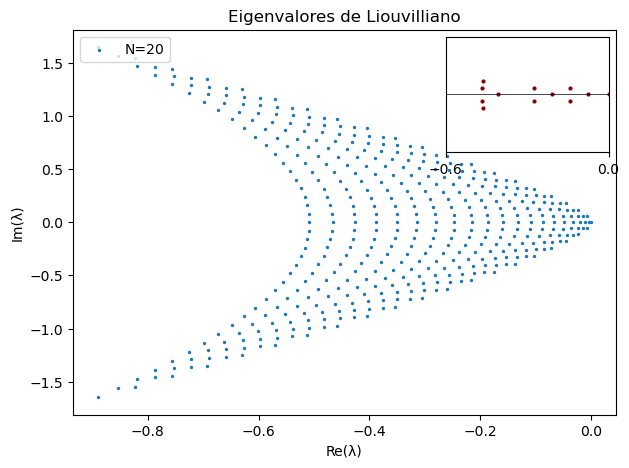

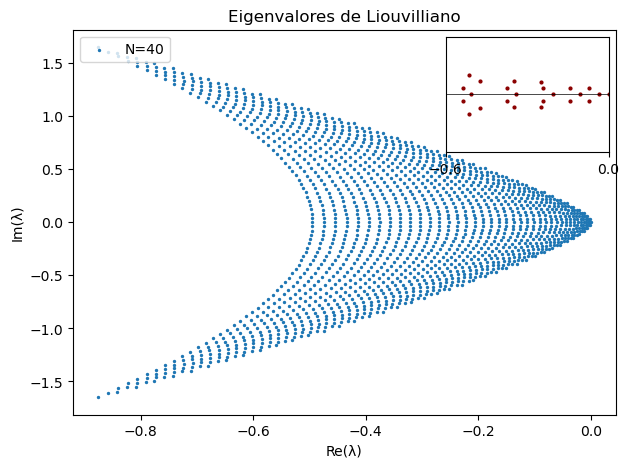

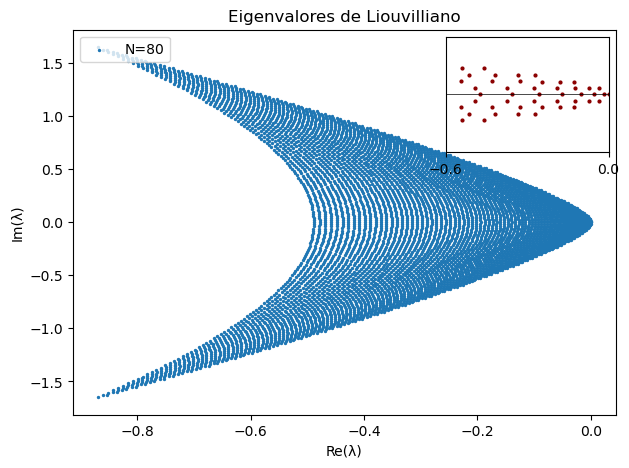

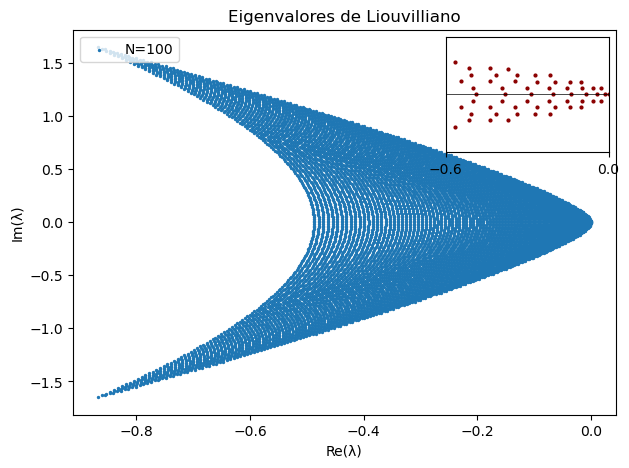

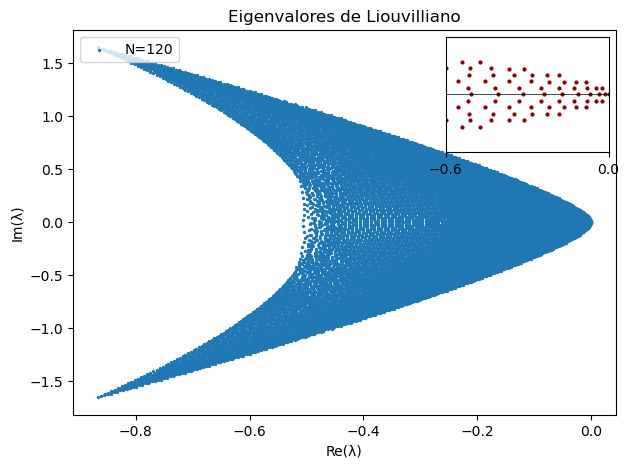

In [44]:

k=1    
for Nb, eigs in eigenvalues.items():
    fig, ax = plt.subplots(figsize=(7,5))

    # Grafica principal
    ax.scatter(np.real(eigs)/Nb*k, np.imag(eigs)/Nb*k, label=f'N={Nb}', s=2)
    ax.set_xlabel("Re(λ)")
    ax.set_ylabel("Im(λ)")
    ax.set_title("Eigenvalores de Liouvilliano")
    ax.legend(loc='upper left')
    # -------------------------
    # Zoom
    # -------------------------
    axins = inset_axes(ax, width="30%", height="30%", loc='upper right')

    axins.scatter(np.real(eigs)/k, np.imag(eigs)/k, s=4, c='darkred')

    # Limites de la region a ampliar
    x1, x2 = -0.6, 0
    y1, y2 = -10, 10

    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.axhline(0, c='black', lw=0.5)

    # Opcional: quitar labels pequeños
    axins.tick_params(axis='y',
                  direction='out',
                  labelsize=10,
                  pad=0)
    axins.set_xticks([x1,x2])
    axins.set_yticks([])
    
    plt.show()


    # Si se escala con el tamaño del sistema, se normaliza la escala cuando divido por el Nb (No. spin en la frontera).

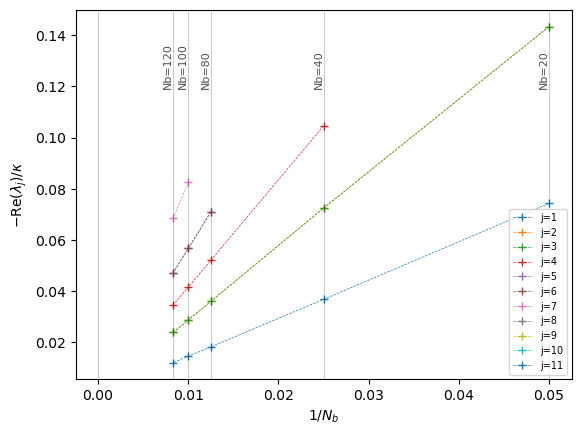

In [45]:
real_scaling = {}

eps = 0.5

for Nb, eigs in eigenvalues.items():

    # Ordenarlos de mayor a menor, 
    # La funcion argsort devuelve un array con las posiciones de menor a mayor entonces lo invertimos con [::-1]
    eigs_sorted = eigs[np.argsort(np.real(eigs))[::-1]]

    selected = []

    # Aquí sec considera el criterio que hace el paper j^2/Nb < epsilon, en este codigo eps = 0.5
    for j, eig in enumerate(eigs_sorted):

        nu = j**2 / Nb

        if nu < eps:
            selected.append((j, np.real(eig)/k))

    real_scaling[Nb] = selected

max_j = 12

for j in range(1, max_j):

    x = []
    y = []

    for Nb in sorted(real_scaling.keys()):    # Este loop corre por 20,40,80,...,200

        data = real_scaling[Nb]

        if j < len(data):

            x.append(1/Nb)
            y.append(-data[j][1]) # -Re(lambda)
    plt.plot(x, y, '+--', label=f'j={j}', lw=0.5)
plt.xlabel(r'$1/N_b$')
plt.ylabel(r'$-\mathrm{Re}(\lambda_j)/\kappa$')
plt.axvline(0, lw=0.5, c='black', alpha=0.3)

for Nb in sorted(real_scaling.keys()):
    plt.axvline(1/Nb, lw=0.5, c='black', alpha=0.3)
    ymin, ymax = plt.ylim()

    plt.text(
        1/Nb,
        ymax*0.8,
        f'Nb={Nb}',
        rotation=90,
        fontsize=8,
        ha='right',
        alpha=0.7
    )
plt.legend(fontsize='x-small', loc = 'lower right')
plt.show()

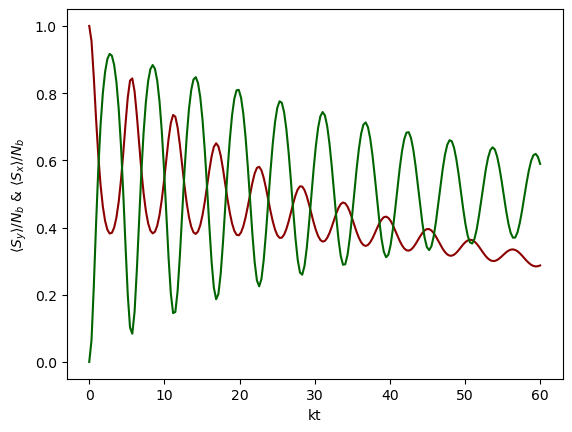

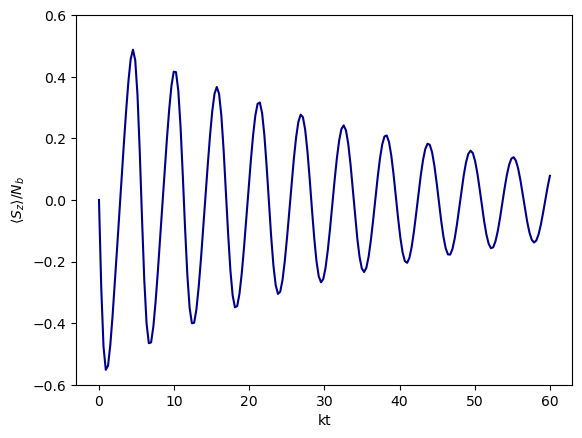

In [57]:
S = Nb/2
t = results[120].times
Sz = results[120].expect[3]
# rho0 = all spin up in x
# Dinamica
'''
plt.plot( k*t, results[120].expect[0]/S, c='red')
plt.xlabel("kt")
plt.ylabel(r"$ langle S^2  rangle / N_b$")
plt.axhline(0, c='black')
'''

plt.plot( k*t, results[120].expect[1]/S, c='darkred')
plt.xlabel("kt")
plt.ylabel(r"$\langle S_x\rangle / N_b$")


plt.plot( k*t, results[120].expect[2]/S, c='darkgreen')
plt.xlabel("kt")
plt.ylabel(r"$\langle S_y\rangle / N_b$ & $\langle S_x\rangle / N_b$")
plt.show()


plt.plot( k*t, Sz/S, c='darkblue')
plt.xlabel("kt")
plt.ylabel(r"$\langle S_z\rangle / N_b$")
plt.ylim(-0.6,0.6)
#plt.savefig("dyn100z.png")
plt.show()



